# Detecção de Anomalias (Stage 1)

## Objetivo deste notebook

Implementar a primeira etapa da arquitetura two-stage: um filtro
não-supervisionado de anomalias, treinado exclusivamente sobre transações
legítimas, capaz de reduzir drasticamente o volume de transações analisadas
antes de aplicar o classificador supervisionado (Stage 2).

## Por que treinar apenas com transações legítimas

Fraude rotulada é escassa (399 casos no conjunto de treino) e enviesada
representando apenas os padrões de fraude já identificados no passado, não
necessariamente táticas futuras. Um modelo não-supervisionado que aprende
o perfil do comportamento **normal** tende a generalizar melhor para
detectar desvios novos, em vez de memorizar as poucas fraudes conhecidas.
Essa é a lógica central que justifica a arquitetura two-stage.

## O que será feito

**1. Carregamento dos dados processados**

Leitura de `train_processed.parquet` e `test_processed.parquet` (produto
do notebook 02), já com encoding cíclico de Hour e RobustScaler aplicado
em Amount.

**2. Isolamento das transações legítimas para treino**

Filtragem do conjunto de treino para reter apenas `Class == 0` — essas
transações serão usadas para ajustar os modelos de detecção de anomalia.

**3. Treinamento de três algoritmos não-supervisionados**

- **Isolation Forest** (algoritmo principal da arquitetura)
- **Local Outlier Factor (LOF)** (comparação)
- **One-Class SVM** (comparação)

**4. Avaliação comparativa dos três algoritmos**

Como não há classificação binária direta nesta etapa, o score de anomalia
de cada modelo é tratado como proxy de classificador, avaliado por:
- PR-AUC (usando o score de anomalia como probabilidade)
- Recall@top-k% (quanto das fraudes reais ficam concentradas nos scores
  mais anômalos)

**5. Definição do corte de filtragem**

Escolha do percentual de transações mais anômalas que avançará para o
Stage 2 (ex: top 10-20% mais suspeitas), balanceando redução de volume
(até 90%, conforme objetivo do projeto) contra preservação do recall de
fraude real.

**6. Validação do corte escolhido**

Checagem explícita de quantas fraudes reais (do treino e do teste) são
preservadas no subconjunto filtrado, métrica crítica, já que qualquer
fraude descartada nesta etapa não poderá ser recuperada pelo Stage 2.

**7. Persistência de artefatos**

Salvamento do modelo de Stage 1 escolhido e dos subconjuntos filtrados
(treino e teste) para uso no Stage 2.

## Métrica crítica desta etapa

Diferente do Stage 2, aqui a métrica mais importante não é a qualidade
geral do ranking de anomalias, mas sim **quanto recall de fraude é
preservado no corte escolhido**. Se o Stage 1 descarta uma fraude real do
funil, essa transação nunca mais poderá ser classificada corretamente porque  
não há como o Stage 2 recuperar um caso que já foi filtrado para fora.



In [1]:
# ================================================================
# Detecção de Anomalias (Isolation Forest)
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import precision_recall_curve, auc

sns.set_theme(style="whitegrid", palette="muted")

# ----------------------------------------------------------------
# Carrega os dados processados no notebook 02
# ----------------------------------------------------------------
caminho_dados = "/content/drive/MyDrive/fraud-detection-two-stage/data/processed"

df_treino = pd.read_parquet(f"{caminho_dados}/train_processed.parquet")
df_teste  = pd.read_parquet(f"{caminho_dados}/test_processed.parquet")

# Features de entrada (tudo menos o target e o identificador de rastreabilidade)
features = [col for col in df_treino.columns if col not in ["Class", "transaction_id"]]

# Confirma presença do transaction_id antes de seguir
assert "transaction_id" in df_treino.columns and "transaction_id" in df_teste.columns, \
    "ERRO: transaction_id ausente — reexecute o notebook 02 corrigido antes de continuar!"

print(f"Treino: {df_treino.shape[0]:,} transações | {df_treino['Class'].sum()} fraudes")
print(f"Teste : {df_teste.shape[0]:,} transações | {df_teste['Class'].sum()} fraudes")
print(f"Features usadas: {len(features)}")

Treino: 226,982 transações | 399 fraudes
Teste : 56,744 transações | 74 fraudes
Features usadas: 31


In [2]:
# ----------------------------------------------------------------
# Treino do Stage 1 usa apenas transações legítimas
# ----------------------------------------------------------------
X_treino_legitimas = df_treino[df_treino["Class"] == 0][features]

# Para avaliação, usamos o treino completo (legítimas + fraudes)
# e o teste completo é preciso das fraudes para medir recall
X_treino_completo = df_treino[features]
y_treino_completo = df_treino["Class"]

X_teste_completo = df_teste[features]
y_teste_completo = df_teste["Class"]

print(f"Transações legítimas para treino do Stage 1: {X_treino_legitimas.shape[0]:,}")

Transações legítimas para treino do Stage 1: 226,583


In [3]:
# ----------------------------------------------------------------
# Treinamento — Isolation Forest, LOF, One-Class SVM
# ----------------------------------------------------------------
# Todos treinados apenas com transações legítimas.
# contamination='auto' ou um valor de referência é usado apenas
# como parâmetro interno do algoritmo, não define o corte final
# de filtragem (isso será decidido pela curva de sensibilidade).

RANDOM_STATE = 42

# Isolation Forest — algoritmo principal da arquitetura
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.01,  # estimativa inicial, não é o corte final
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_treino_legitimas)

# score_samples: quanto MAIOR, mais normal. Invertendo para
# que score mais ALTO = mais anômalo (convenção mais intuitiva)
score_iso_treino = -iso_forest.score_samples(X_treino_completo)
score_iso_teste  = -iso_forest.score_samples(X_teste_completo)

print("Isolation Forest treinado.")

# ----------------------------------------------------------------
# Local Outlier Factor — usa novelty=True para permitir
# predição em dados não vistos no fit (padrão é só fit_predict)
# ----------------------------------------------------------------
lof = LocalOutlierFactor(
    n_neighbors=20,
    novelty=True,
    n_jobs=-1
)
lof.fit(X_treino_legitimas)

score_lof_treino = -lof.score_samples(X_treino_completo)
score_lof_teste  = -lof.score_samples(X_teste_completo)

print("LOF treinado.")

# ----------------------------------------------------------------
# One-Class SVM — treinado com todas as transações legítimas
# ----------------------------------------------------------------
# Sem amostragem: dataset completo de transações legítimas de treino.

ocsvm = OneClassSVM(kernel="rbf", nu=0.01, gamma="scale")
ocsvm.fit(X_treino_legitimas)

score_ocsvm_treino = -ocsvm.score_samples(X_treino_completo)
score_ocsvm_teste  = -ocsvm.score_samples(X_teste_completo)

print(f"One-Class SVM treinado com {X_treino_legitimas.shape[0]:,} transações legítimas.")

Isolation Forest treinado.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


LOF treinado.
One-Class SVM treinado com 226,583 transações legítimas.


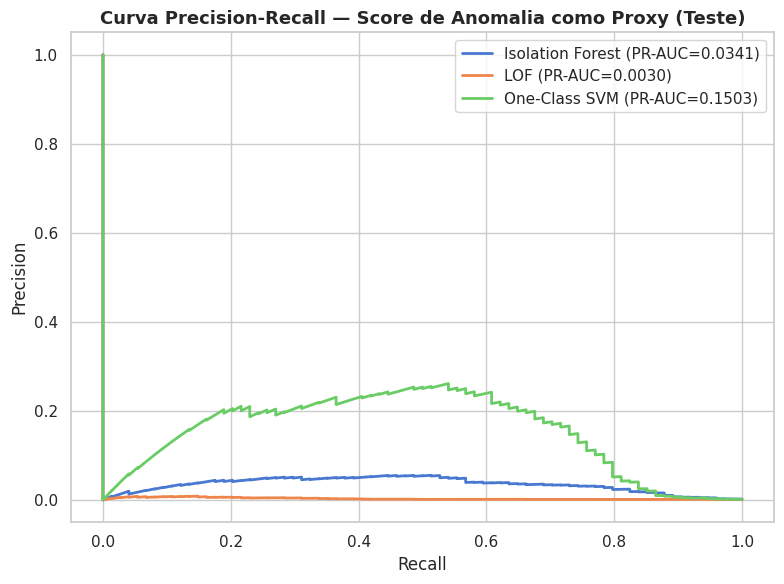

In [4]:
# ----------------------------------------------------------------
# Avaliação — PR-AUC usando o score de anomalia como proxy
# ----------------------------------------------------------------
# Quanto maior o score de anomalia, mais "suspeita" a transação.
# Usamos esse score como se fosse a probabilidade de um
# classificador, e calculamos PR-AUC no CONJUNTO DE TESTE
# (avaliação real, fora da amostra de treino).

modelos_scores_teste = {
    "Isolation Forest": score_iso_teste,
    "LOF": score_lof_teste,
    "One-Class SVM": score_ocsvm_teste
}

resultados_pr_auc = {}

fig, ax = plt.subplots(figsize=(8, 6))

for nome, score in modelos_scores_teste.items():
    precision, recall, _ = precision_recall_curve(y_teste_completo, score)
    pr_auc = auc(recall, precision)
    resultados_pr_auc[nome] = pr_auc
    ax.plot(recall, precision, label=f"{nome} (PR-AUC={pr_auc:.4f})", linewidth=2)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall — Score de Anomalia como Proxy (Teste)",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### Análise — Avaliação PR-AUC dos Modelos de Detecção de Anomalia (Stage 1)

Foi avaliado os três algoritmos não-supervisionados (Isolation Forest, Local
Outlier Factor e One-Class SVM) tratando seus scores de anomalia como
proxy de um classificador, calculando PR-AUC sobre o conjunto de **teste**
(fora da amostra usada no treino).

**Resultados:**

| Modelo | PR-AUC |
|---|---|
| One-Class SVM | 0,1503 |
| Isolation Forest | 0,0341 |
| Local Outlier Factor | 0,0030 |

**Interpretação em relação à baseline aleatória:**

PR-AUC não deve ser interpretado em valor absoluto, e sim relativo à
prevalência da classe positiva no conjunto de teste que funciona como
baseline de um classificador aleatório. Com 74 fraudes em 56.744
transações de teste, a baseline aleatória é de aproximadamente **0,0013**.

| Modelo | PR-AUC | Vezes melhor que aleatório |
|---|---|---|
| One-Class SVM | 0,1503 | ~115x |
| Isolation Forest | 0,0341 | ~26x |
| Local Outlier Factor | 0,0030 | ~2,3x |

Sob essa lente, **One-Class SVM** apresenta desempenho consideravelmente
superior aos demais, concentrando fraudes reais nos scores de anomalia
mais altos de forma bem mais eficaz. **Isolation Forest** apresenta
desempenho intermediário, ainda relevante frente à baseline. **LOF**, por
outro lado, performa muito próximo do acaso, indicando que praticamente
não captura sinal de fraude nesta configuração.

**Hipótese para o baixo desempenho do LOF:** o algoritmo é baseado em
densidade local, métrica que tende a perder significância em espaços de
alta dimensionalidade (neste caso, 31 features) esse fenômeno é conhecido como
maldição da dimensionalidade. Isolation Forest e One-Class SVM lidam
melhor com esse cenário por não dependerem diretamente de distância entre
vizinhos locais.

**Decisão preliminar:** LOF será mantido no notebook apenas como
comparação documentada, mas descartado como candidato ao pipeline de
produção. A escolha final do modelo de Stage 1 será definida com base na
curva de sensibilidade (recall de fraude preservado vs. percentual de
transações retidas), comparando especificamente Isolation Forest e
One-Class SVM.

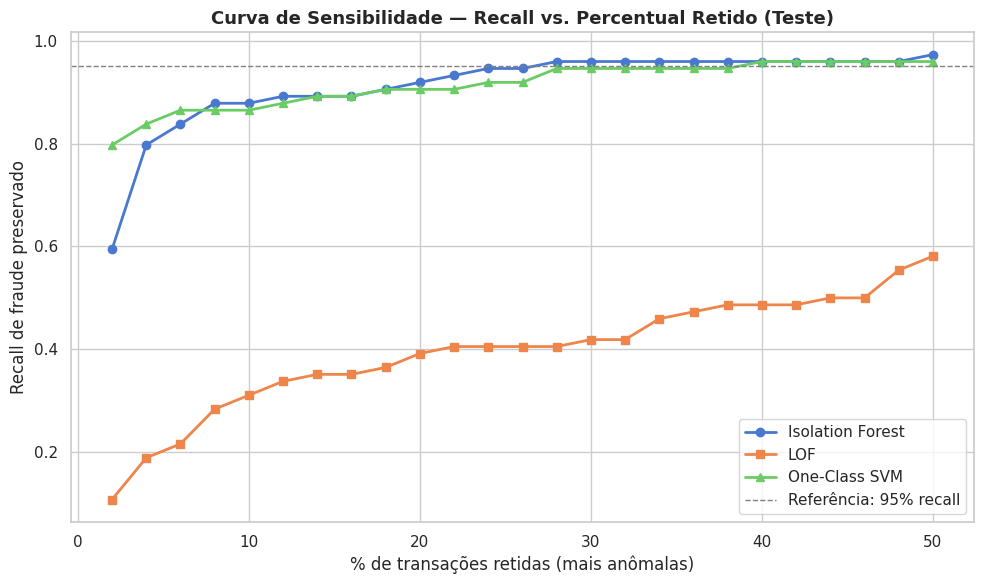

In [5]:
# ----------------------------------------------------------------
# CURVA DE SENSIBILIDADE — o coração da decisão do corte
# ----------------------------------------------------------------
# Para cada percentual de corte (top-k% mais anômalos), medimos
# quantas fraudes REAIS são preservadas nesse subconjunto.
# Isso é feito tanto no treino quanto no teste, para os 3 modelos.

percentuais_corte = np.arange(2, 51, 2)  # de 2% a 50%, de 2 em 2

def calcular_recall_por_corte(scores, y_true, percentuais):
    """Para cada percentual de corte, calcula recall de fraude preservado."""
    resultados = []
    n_total = len(scores)

    for pct in percentuais:
        n_reter = int(n_total * pct / 100)
        # Índices das transações com maior score (mais anômalas)
        indices_top = np.argsort(scores)[-n_reter:]

        fraudes_preservadas = y_true.iloc[indices_top].sum()
        fraudes_totais = y_true.sum()
        recall = fraudes_preservadas / fraudes_totais

        resultados.append({
            "pct_retido": pct,
            "n_transacoes_retidas": n_reter,
            "fraudes_preservadas": fraudes_preservadas,
            "recall": recall
        })

    return pd.DataFrame(resultados)

# Calcula a curva para os três modelos, no conjunto de TESTE
# (avaliação mais realista do que ocorreria em produção)
curva_iso    = calcular_recall_por_corte(score_iso_teste, y_teste_completo, percentuais_corte)
curva_lof    = calcular_recall_por_corte(score_lof_teste, y_teste_completo, percentuais_corte)
curva_ocsvm  = calcular_recall_por_corte(score_ocsvm_teste, y_teste_completo, percentuais_corte)

# ----------------------------------------------------------------
# Visualização da curva de sensibilidade
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(curva_iso["pct_retido"], curva_iso["recall"],
        marker="o", label="Isolation Forest", linewidth=2)
ax.plot(curva_lof["pct_retido"], curva_lof["recall"],
        marker="s", label="LOF", linewidth=2)
ax.plot(curva_ocsvm["pct_retido"], curva_ocsvm["recall"],
        marker="^", label="One-Class SVM", linewidth=2)

ax.axhline(0.95, color="gray", linestyle="--", linewidth=1,
           label="Referência: 95% recall")
ax.set_xlabel("% de transações retidas (mais anômalas)")
ax.set_ylabel("Recall de fraude preservado")
ax.set_title("Curva de Sensibilidade — Recall vs. Percentual Retido (Teste)",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# ----------------------------------------------------------------
# Tabela comparativa — Isolation Forest vs. One-Class SVM
# ----------------------------------------------------------------
comparativo = pd.DataFrame({
    "pct_retido": curva_iso["pct_retido"],
    "recall_isolation_forest": curva_iso["recall"],
    "recall_one_class_svm": curva_ocsvm["recall"],
})

comparativo["diferenca"] = (comparativo["recall_isolation_forest"]
                             - comparativo["recall_one_class_svm"])

print("Comparativo Isolation Forest vs. One-Class SVM:")
print(comparativo.to_string(index=False))

Comparativo Isolation Forest vs. One-Class SVM:
 pct_retido  recall_isolation_forest  recall_one_class_svm  diferenca
          2                 0.594595              0.797297  -0.202703
          4                 0.797297              0.837838  -0.040541
          6                 0.837838              0.864865  -0.027027
          8                 0.878378              0.864865   0.013514
         10                 0.878378              0.864865   0.013514
         12                 0.891892              0.878378   0.013514
         14                 0.891892              0.891892   0.000000
         16                 0.891892              0.891892   0.000000
         18                 0.905405              0.905405   0.000000
         20                 0.918919              0.905405   0.013514
         22                 0.932432              0.905405   0.027027
         24                 0.945946              0.918919   0.027027
         26                 0.945946      

### Análise — Curva de Sensibilidade e Escolha do Modelo de Stage 1

Avaliamos o recall de fraude preservado em função do percentual de
transações retidas (as mais anômalas, segundo cada modelo), no conjunto
de teste, para os três algoritmos testados.

**LOF foi confirmado como inadequado**: preserva apenas ~58% de recall
mesmo retendo 50% das transações — descartado como candidato ao Stage 1.

**Comparativo direto entre Isolation Forest e One-Class SVM:**

| % retido | Recall Isolation Forest | Recall One-Class SVM | Diferença |
|---|---|---|---|
| 2% | 59,5% | 79,7% | OCSVM +20,3pp |
| 8% | 87,8% | 86,5% | IF +1,4pp |
| 28% | 95,9% | 94,6% | IF +1,4pp |
| 40% | 95,9% | 95,9% | Empate |

Em cortes muito agressivos (2-6%), o One-Class SVM concentra melhor as
fraudes mais evidentes. A partir de 8% de retenção, porém, o Isolation
Forest assume vantagem e a mantém até o final da curva avaliada.

**Ponto de decisão — corte de 28%:** Isolation Forest atinge 95,9% de
recall (71 de 74 fraudes preservadas), superando o One-Class SVM (94,6%,
70 de 74 fraudes) no mesmo corte. Para alcançar o mesmo nível de recall
que o Isolation Forest obtém em 28%, o One-Class SVM precisaria reter 40%
das transações quase 43% a mais de volume no funil.

**Decisão final: Isolation Forest, com corte de filtragem em 28%.**

Justificativa:
1. Recall superior ou equivalente ao One-Class SVM na maior parte da
   faixa de corte relevante (≥8%).
2. Maior eficiência porque atinge o patamar de recall desejado (≥95%)
   retendo significativamente menos transações.
3. Vantagem computacional relevante, tanto para reprocessamento quanto
   para a futura API de produção, dado que Isolation Forest escala
   melhor que One-Class SVM em bases maiores.

**Trade-off:** o corte de 28% está bem acima da
meta original de redução de até 90% do volume (que corresponderia a um
corte de 10%). Essa escolha prioriza recall de fraude sobre a meta de
eficiência de volume, já que qualquer fraude descartada no Stage 1 é
irrecuperável pelo Stage 2 e o custo de processar mais transações no
Stage 2 é operacional, enquanto o custo de recall perdido é uma fraude
não detectada.

## Conclusão Geral — Stage 1: Detecção de Anomalias

Este notebook implementou e validou a primeira etapa da arquitetura
two-stage: um filtro não-supervisionado de anomalias, treinado
exclusivamente sobre transações legítimas, responsável por reduzir o
volume de transações antes da aplicação do classificador supervisionado
(Stage 2).

**1. Três algoritmos testados, um claramente descartado**

Isolation Forest, Local Outlier Factor (LOF) e One-Class SVM foram
treinados com as transações legítimas do conjunto de treino e avaliados
no conjunto de teste, usando o score de anomalia como proxy de
classificador (PR-AUC) e, principalmente, a curva de recall de fraude
preservado por percentual de corte. **LOF apresentou desempenho próximo
ao de um classificador aleatório** (PR-AUC de 0,0030, apenas ~2,3x melhor
que a baseline) e foi descartado como candidato ao pipeline e a hipótese
levantada é a perda de eficácia de métricas de densidade local em espaços
de alta dimensionalidade (31 features).

**2. Isolation Forest e One-Class SVM comparados em detalhe**

Embora o One-Class SVM tenha vencido na PR-AUC agregada (0,1503 vs 0,0341)
e levado vantagem em cortes muito agressivos (2-6% de retenção), o
**Isolation Forest superou ou empatou com o One-Class SVM em toda a faixa
de corte relevante (a partir de 8% de retenção)**, além de ser
significativamente mais eficiente atingindo o mesmo nível de recall
(~95,9%) com bem menos volume retido.

**3. Modelo e corte definidos**

**Isolation Forest, com corte de filtragem em 28%**, foi escolhido como
modelo de Stage 1. Nesse ponto, 71 das 74 fraudes do conjunto de teste
são preservadas (recall de 95,9%), enquanto ~72% do volume total de
transações é descartado do funil antes do Stage 2.

**4. Trade-off assumido conscientemente**

A meta original do projeto previa redução de até 90% do volume (corte de
~10%), mas nesse patamar o recall cairia para 87,8% descartando mais de
12% das fraudes reais de forma irrecuperável. A decisão final priorizou
recall sobre a meta de redução de volume, já que uma fraude descartada
no Stage 1 nunca poderá ser recuperada pelo Stage 2, enquanto o custo de
processar um volume maior no Stage 2 é apenas operacional/computacional.

**5. Limitação**

Com apenas 74 fraudes no conjunto de teste, cada fraude individual
representa ~1,35 ponto percentual de recall e a análise comparativa entre
modelos, embora consistente ao longo de toda a curva, deve ser
interpretada com essa granularidade amostral em mente.

In [7]:
# ----------------------------------------------------------------
# APLICAÇÃO DO FILTRO — Isolation Forest, corte de 28%
# ----------------------------------------------------------------
# Gera os subconjuntos filtrados que alimentarão o Stage 2.
# O corte é aplicado sobre TODO o conjunto (treino e teste),
# não apenas sobre as legítimas usadas no fit.

CORTE_ESCOLHIDO_PCT = 28

def filtrar_top_anomalias(df_original, scores, pct_retido):
    """Retorna o subconjunto com as pct_retido% transações mais anômalas."""
    n_total = len(df_original)
    n_reter = int(n_total * pct_retido / 100)

    indices_top = np.argsort(scores)[-n_reter:]
    df_filtrado = df_original.iloc[indices_top].copy()
    df_filtrado["anomaly_score"] = scores[indices_top]

    return df_filtrado

df_treino_filtrado = filtrar_top_anomalias(df_treino, score_iso_treino, CORTE_ESCOLHIDO_PCT)
df_teste_filtrado  = filtrar_top_anomalias(df_teste, score_iso_teste, CORTE_ESCOLHIDO_PCT)

# Checagem de sanidade — confirma que o recall bate com o esperado
recall_treino = df_treino_filtrado["Class"].sum() / df_treino["Class"].sum()
recall_teste  = df_teste_filtrado["Class"].sum() / df_teste["Class"].sum()

print(f"Treino filtrado: {df_treino_filtrado.shape[0]:,} transações | "
      f"{df_treino_filtrado['Class'].sum()} fraudes | recall={recall_treino:.4f}")
print(f"Teste filtrado : {df_teste_filtrado.shape[0]:,} transações | "
      f"{df_teste_filtrado['Class'].sum()} fraudes | recall={recall_teste:.4f}")

Treino filtrado: 63,554 transações | 376 fraudes | recall=0.9424
Teste filtrado : 15,888 transações | 71 fraudes | recall=0.9595


In [8]:
# ----------------------------------------------------------------
# PERSISTÊNCIA — modelo, subconjuntos filtrados e metadados
# ----------------------------------------------------------------

import joblib
import json

caminho_base    = "/content/drive/MyDrive/fraud-detection-two-stage"
caminho_dados   = f"{caminho_base}/data/processed"
caminho_modelos = f"{caminho_base}/models"

# 1. Modelo Isolation Forest treinado
joblib.dump(iso_forest, f"{caminho_modelos}/isolation_forest_stage1.pkl")

# 2. Subconjuntos filtrados (entrada do Stage 2)
df_treino_filtrado.to_parquet(f"{caminho_dados}/train_stage1_filtered.parquet", index=False)
df_teste_filtrado.to_parquet(f"{caminho_dados}/test_stage1_filtered.parquet", index=False)

# 3. Metadados do Stage 1 — registro das decisões tomadas
# Importante para rastreabilidade e para o notebook 07 (monitoramento)
metadados_stage1 = {
    "modelo_escolhido": "Isolation Forest",
    "corte_pct_retido": CORTE_ESCOLHIDO_PCT,
    "n_estimators": 200,
    "contamination_fit": 0.01,
    "recall_treino": round(recall_treino, 4),
    "recall_teste": round(recall_teste, 4),
    "fraudes_treino_total": int(df_treino["Class"].sum()),
    "fraudes_treino_preservadas": int(df_treino_filtrado["Class"].sum()),
    "fraudes_teste_total": int(df_teste["Class"].sum()),
    "fraudes_teste_preservadas": int(df_teste_filtrado["Class"].sum()),
    "pr_auc_teste": {
        "isolation_forest": round(resultados_pr_auc["Isolation Forest"], 4),
        "lof": round(resultados_pr_auc["LOF"], 4),
        "one_class_svm": round(resultados_pr_auc["One-Class SVM"], 4)
    }
}

with open(f"{caminho_modelos}/stage1_metadata.json", "w") as f:
    json.dump(metadados_stage1, f, indent=2)

print("Artefatos salvos com sucesso:")
print(f"  Modelo    : {caminho_modelos}/isolation_forest_stage1.pkl")
print(f"  Treino    : {caminho_dados}/train_stage1_filtered.parquet")
print(f"  Teste     : {caminho_dados}/test_stage1_filtered.parquet")
print(f"  Metadados : {caminho_modelos}/stage1_metadata.json")

Artefatos salvos com sucesso:
  Modelo    : /content/drive/MyDrive/fraud-detection-two-stage/models/isolation_forest_stage1.pkl
  Treino    : /content/drive/MyDrive/fraud-detection-two-stage/data/processed/train_stage1_filtered.parquet
  Teste     : /content/drive/MyDrive/fraud-detection-two-stage/data/processed/test_stage1_filtered.parquet
  Metadados : /content/drive/MyDrive/fraud-detection-two-stage/models/stage1_metadata.json


In [9]:
# Confirma que transaction_id foi preservado nos datasets filtrados
assert "transaction_id" in df_treino_filtrado.columns
assert "transaction_id" in df_teste_filtrado.columns
assert df_treino_filtrado["transaction_id"].is_unique
assert df_teste_filtrado["transaction_id"].is_unique
print(f"\ntransaction_id preservado corretamente nos datasets filtrados.")


transaction_id preservado corretamente nos datasets filtrados.
